# 03 Graph Metrics Analysis

Load the Pearson network products, compute global and node-level metrics, and save summary plots.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, INTERIM_DATA_DIR, PROCESSED_DATA_DIR
from src.graph_metrics import compute_basic_metrics, compute_node_metrics, save_node_metrics
from src.network_construction import build_graph_from_adjacency
from src.visualisation import plot_degree_histogram, plot_degree_map, plot_link_length_distribution, plot_metric_map

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
A = np.load(PROCESSED_DATA_DIR / "pearson_adjacency.npy")
node_metadata = pd.read_parquet(INTERIM_DATA_DIR / "node_metadata.parquet")
G = build_graph_from_adjacency(A, node_metadata)
G

In [3]:
global_metrics = compute_basic_metrics(G)
(PROCESSED_DATA_DIR / "pearson_global_metrics.json").write_text(json.dumps(global_metrics, indent=2))
global_metrics

{'n_nodes': 723,
 'n_edges': 2610,
 'edge_density': 0.009999885058792428,
 'average_degree': 7.219917012448133,
 'average_clustering': 0.42276936376556884,
 'largest_connected_component_size': 428,
 'average_shortest_path_length_lcc': 11.389853137516688}

In [4]:
node_metrics = compute_node_metrics(G)
save_node_metrics(node_metrics, PROCESSED_DATA_DIR / "pearson_node_metrics.parquet")
node_metrics.head()

,node_id,degree,degree_centrality,clustering,betweenness_centrality,lat,lon,original_node_id,missing_fraction
0,0,0,0.0,0.0,0.0,-87.5,2.5,36.0,0.138889
1,1,0,0.0,0.0,0.0,-77.5,-27.5,174.0,0.117647
2,2,0,0.0,0.0,0.0,-77.5,107.5,201.0,0.217320
3,3,0,0.0,0.0,0.0,-77.5,167.5,213.0,0.122549
4,4,0,0.0,0.0,0.0,-72.5,12.5,254.0,0.217320


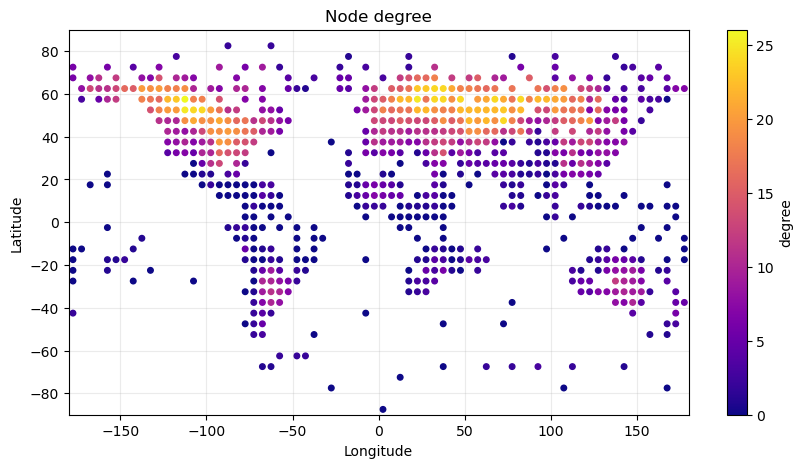

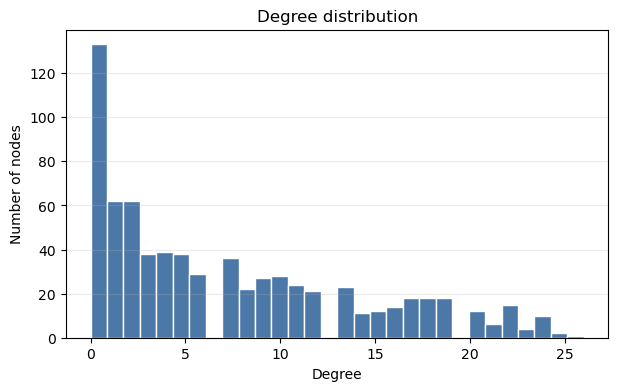

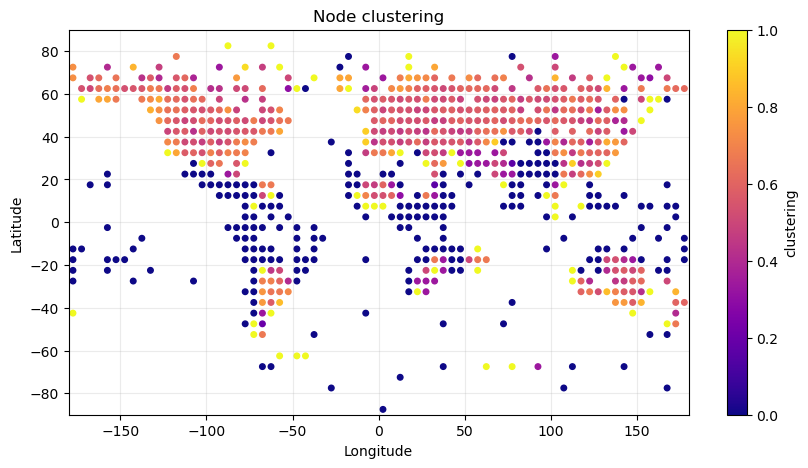

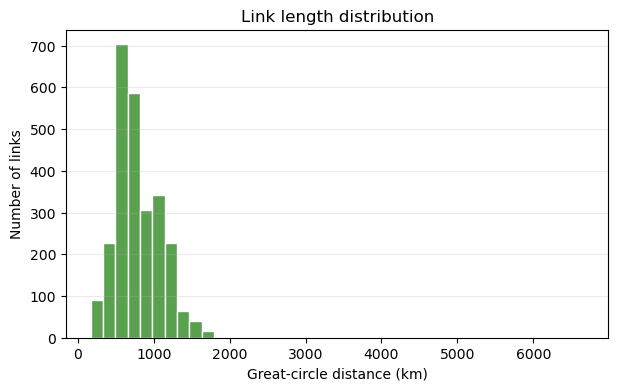

In [5]:
plot_degree_map(node_metrics, save_path=FIGURES_DIR / "pearson_degree_map.png");
plot_degree_histogram(node_metrics, save_path=FIGURES_DIR / "pearson_degree_histogram.png");
plot_metric_map(node_metrics, "clustering", save_path=FIGURES_DIR / "pearson_clustering_map.png");
plot_link_length_distribution(G, save_path=FIGURES_DIR / "pearson_link_length_distribution.png");